# ESM-C embeddings for PF00001 (Class A GPCRs, human)

Recompute `esmc_300m` per-residue embeddings for the 722 human PF00001 proteins
(`PF00001.9606.fa`, headers `>9606.<uniprot>`) and save them to
`proteins/gpcr_esmc_300m_embeddings/`.

Then mean-pool to one 960-d vector per protein and visualise:
1. **UMAP** (static) coloured by group: OR **class 1** / **class 2** / **neurotransmitter** / **the rest**.
2. **UMAP** (interactive plotly, saved to HTML).
3. **PCA** with the zero-axes highlighted.

Group sources — seqid lists from the PF00001 fasttree (`9606.<uniprot>`):
- class 1 &larr; `PF00001.9606.clustalo.gt01.lg.fasttree.classI_seqids.txt`
- class 2 &larr; `PF00001.9606.clustalo.gt01.lg.fasttree.classII_seqids.txt`
- neurotransmitter &larr; `PF00001.9606.clustalo.gt01.lg.fasttree.NT_seqids.txt`
- the rest &larr; everything else.

In [21]:
from pathlib import Path
import torch
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

# from tqdm.auto import tqdm
# from esm.models.esmc import ESMC
# from esm.sdk.api import ESMProtein, LogitsConfig

# ---- paths (relative to this notebook: Model/Embeddings/) ----
PHYLO    = Path("../../Phylogenetic_Analysis/data")
AP       = PHYLO / "GPCR_classA/AP"
FASTA_PATH = AP / "PF00001.9606.fa"
# group seqid files from the PF00001 fasttree (seqids "9606.<uniprot>")
C1_PATH    = AP / "PF00001.9606.clustalo.gt01.lg.fasttree.classI_seqids.txt"
C2_PATH    = AP / "PF00001.9606.clustalo.gt01.lg.fasttree.classII_seqids.txt"
NT_PATH    = AP / "PF00001.9606.clustalo.gt01.lg.fasttree.NT_seqids.txt"

OUT_DIR  = Path("proteins/gpcr_esmc_300m_embeddings")   # .npy embeddings
FIG_DIR  = Path("figures")                              # all saved figures / html
FIG_DIR.mkdir(exist_ok=True)

for p in (FASTA_PATH, C1_PATH, C2_PATH, NT_PATH):
    assert p.exists(), f"Missing input: {p}"
print("Inputs OK ->", FASTA_PATH.name)

Inputs OK -> PF00001.9606.fa


## esm-c — extract per-residue embeddings

In [2]:
def compute_esmc_embeddings(fasta_path, output_dir=OUT_DIR):
    """Per-residue esmc_300m embeddings; one .npy per protein named `<uniprot>.<taxid>.npy`.
    FASTA headers look like `>9606.<uniprot>` (i.e. `<taxid>.<uniprot>`)."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    model = ESMC.from_pretrained("esmc_300m").to(device).eval()

    out_dir = Path(output_dir)
    out_dir.mkdir(exist_ok=True, parents=True)

    saved_count = 0
    for rec in tqdm(SeqIO.parse(str(fasta_path), "fasta"), desc="Embedding proteins"):
        header = rec.id                      # "<taxid>.<uniprot>", e.g. "9606.Q96R09"
        seq    = str(rec.seq)

        try:
            taxid, uniprot = header.split(".", 1)
            filename = f"{uniprot}.{taxid}.npy"
        except ValueError:
            print(f"Skipping malformed header: {header}")
            continue

        protein = ESMProtein(sequence=seq)
        tok = model.encode(protein).to(device)

        with torch.no_grad():
            out = model.logits(tok, LogitsConfig(sequence=True, return_embeddings=True))
            emb = out.embeddings.squeeze(0).cpu().numpy()  # [L+2, 960]

        np.save(out_dir / filename, emb)
        saved_count += 1
        if saved_count % 100 == 0:
            print(f"Saved {saved_count}: {filename}  shape {emb.shape}")

    print(f"Finished. Saved {saved_count} embeddings to {out_dir}")
    return out_dir

In [3]:
emb_dir = compute_esmc_embeddings(FASTA_PATH, output_dir=OUT_DIR)

Device: cuda


/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 81840.08it/s]
Embedding proteins: 100it [00:28,  3.86it/s]

Saved 100: P0C604.9606.npy  shape (317, 960)


Embedding proteins: 200it [00:54,  3.46it/s]

Saved 200: Q9GZQ6.9606.npy  shape (432, 960)


...

Saved 600: P37288.9606.npy  shape (420, 960)


Embedding proteins: 700it [03:10,  4.20it/s]

Saved 700: P0C626.9606.npy  shape (316, 960)


Embedding proteins: 722it [03:15,  3.69it/s]

Finished. Saved 722 embeddings to proteins/gpcr_esmc_300m_embeddings


## Load embeddings & mean-pool

Strip BOS/EOS (`emb[1:-1]`) and mean-pool over residues to get one `960`-d vector per protein.

In [22]:
emb_dir = OUT_DIR
assert emb_dir.exists(), f"Folder not found: {emb_dir}"

rows, X = [], []
npy_files = sorted(emb_dir.glob("*.npy"))
print("Found", len(npy_files), "npy files")

for fp in npy_files:
    uniprot, tax_id = fp.stem.split(".", 1)
    emb = np.load(fp, mmap_mode="r")     # (L+2, 960)
    emb = emb[1:-1]                      # (L, 960) remove BOS/EOS
    vec = emb.mean(axis=0)               # (960,)

    rows.append({"file": fp.name, "uniprot": uniprot, "tax_id": tax_id, "L": emb.shape[0]})
    X.append(vec)

df = pd.DataFrame(rows)
X = np.vstack(X)
print("Loaded:", X.shape, " (n_proteins, emb_dim)")

Found 722 npy files
Loaded: (722, 960)  (n_proteins, emb_dim)


## Assign groups + correspondence check

Groups come from three seqid lists produced by the PF00001 fasttree (so they map exactly
onto the embedded proteins):
- **class 1** &larr; `...fasttree.classI_seqids.txt`
- **class 2** &larr; `...fasttree.classII_seqids.txt`
- **neurotransmitter** &larr; `...fasttree.NT_seqids.txt`
- **the rest** &larr; everything else.

The check confirms every labelled id is present among the embeddings and that no id falls
into two groups.

In [23]:
import warnings

def load_acc(path):
    """seqids "9606.<uniprot>" -> set of uniprot accessions."""
    return {l.strip().split(".", 1)[1] for l in open(path) if l.strip()}

c1_acc = load_acc(C1_PATH)            # OR class I
c2_acc = load_acc(C2_PATH)            # OR class II
nt_acc = load_acc(NT_PATH)           # neurotransmitters
class_map = {**{a: "class 1" for a in c1_acc}, **{a: "class 2" for a in c2_acc}}

# --- correspondence check ---
emb_acc = set(df["uniprot"])
groups  = {"class 1": c1_acc, "class 2": c2_acc, "neurotransmitter": nt_acc}
for name, s in groups.items():
    missing = sorted(s - emb_acc)
    print(f"{name:16} ids={len(s):3}  missing from embeddings: {len(missing)} -> {missing}")

# no id should belong to two groups
pair_overlaps = {f"{a}&{b}": sorted(groups[a] & groups[b])
                 for a, b in [("class 1", "class 2"), ("class 1", "neurotransmitter"),
                              ("class 2", "neurotransmitter")] if groups[a] & groups[b]}
assert not pair_overlaps, f"group overlaps: {pair_overlaps}"

missing_any = sorted((c1_acc | c2_acc | nt_acc) - emb_acc)
if missing_any:
    warnings.warn(f"{len(missing_any)} labelled id(s) absent from embeddings; skipped: {missing_any}")

def assign_group(acc):
    if acc in nt_acc:
        return "neurotransmitter"
    return class_map.get(acc, "the rest")

df["color_group"] = df["uniprot"].map(assign_group)
print("\ngroup counts:")
print(df["color_group"].value_counts())

class 1          ids= 62  missing from embeddings: 0 -> []
class 2          ids=372  missing from embeddings: 0 -> []
neurotransmitter ids= 42  missing from embeddings: 0 -> []

group counts:
color_group
class 2             372
the rest            246
class 1              62
neurotransmitter     42
Name: count, dtype: int64


## UMAP

In [24]:
import umap

reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.5,
    metric="cosine",
    random_state=42,
)
Z = reducer.fit_transform(X)   # (n, 2)
Z.shape

/home/izirdeli/anaconda3/envs/ete4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/izirdeli/anaconda3/envs/ete4/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(722, 2)

In [25]:
from sklearn.manifold import trustworthiness

#calculate trustworthiness of the UMAP embedding
trust = trustworthiness(X, Z, n_neighbors=50)
print(f"Trustworthiness of the UMAP embedding: {trust:.4f}")

Trustworthiness of the UMAP embedding: 0.9558


## 1. UMAP — static (matplotlib)

Coloured by group: class 1 `#7f1734`, class 2 `#557c99`, neurotransmitter `#000000`,
the rest `#B0B0B0`. `the rest` is drawn first so the highlighted groups sit on top.
Exported as SVG + PNG.

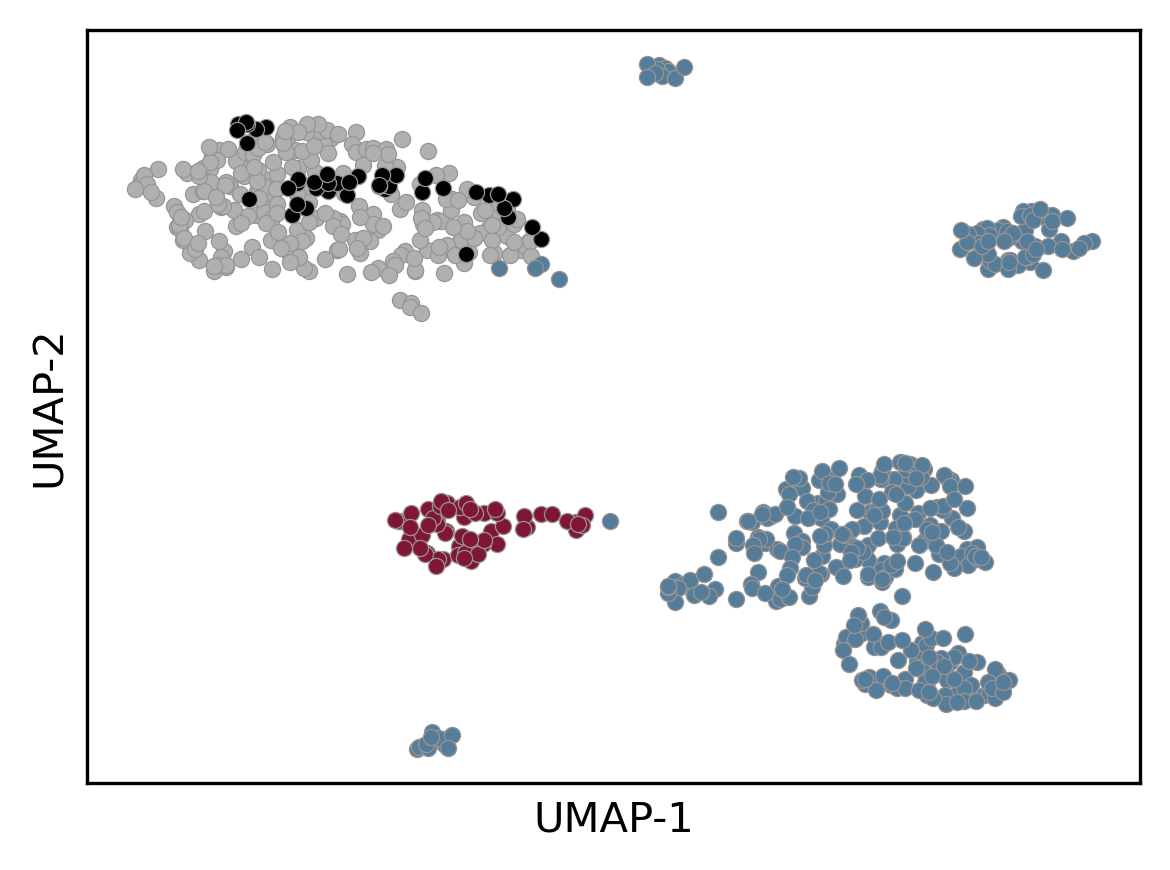

In [26]:
# shared group order + palette (reused by the plotly and PCA cells)
group_order = ["class 1", "class 2", "neurotransmitter", "the rest"]
palette = {
    "class 1":          "#7f1734",
    "class 2":          "#557c99",
    "neurotransmitter": "#000000",
    "the rest":         "#B0B0B0",
}

# UMAP coords attached to metadata
plot_df = df.copy()
plot_df["UMAP-1"] = Z[:, 0]
plot_df["UMAP-2"] = Z[:, 1]

plt.figure(figsize=(4, 3), dpi=300)
# draw "the rest" first so the highlighted groups sit on top
for g in ["the rest", "class 2", "class 1", "neurotransmitter"]:
    sub = plot_df[plot_df["color_group"] == g]
    plt.scatter(sub["UMAP-1"], sub["UMAP-2"], s=15, alpha=1,
                color=palette[g], edgecolors="#999494", linewidth=0.3,
                label=f"{g} (n={len(sub)})")

ax = plt.gca()
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
ax.set_xticks([])
ax.set_yticks([])
#plt.legend(title="group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=6)

plt.tight_layout()
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_umap_ORclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_umap_ORclass.png", bbox_inches="tight", dpi=300)
plt.show()

## 2. UMAP — interactive (plotly)

Same UMAP coordinates and colours, interactive with hover (uniprot, group, length),
saved to `gpcr_pf00001_esmc300m_umap_ORclass.html`.

In [7]:
import plotly.express as px

fig = px.scatter(
    plot_df, x="UMAP-1", y="UMAP-2",
    color="color_group",
    category_orders={"color_group": group_order},
    color_discrete_map=palette,
    hover_name="uniprot",
    hover_data={"color_group": True, "L": True,
                "UMAP-1": ":.2f", "UMAP-2": ":.2f"},
    title="ESM-C (300m) UMAP — OR class 1/2, neurotransmitters, rest",
    width=900, height=650,
)
fig.update_traces(marker=dict(size=7, line=dict(width=0.4, color="black")))
fig.update_layout(legend_title_text="group")

html_path = FIG_DIR / "gpcr_pf00001_esmc300m_umap_ORclass.html"
fig.write_html(str(html_path))
print("saved:", html_path)
#fig.show()

saved: figures/gpcr_pf00001_esmc300m_umap_ORclass.html


## 3. PCA (zero-axes highlighted)

Linear PCA of the same 960-d mean-pooled embeddings, coloured by the same groups.
The x=0 and y=0 axes are drawn as bold reference lines.

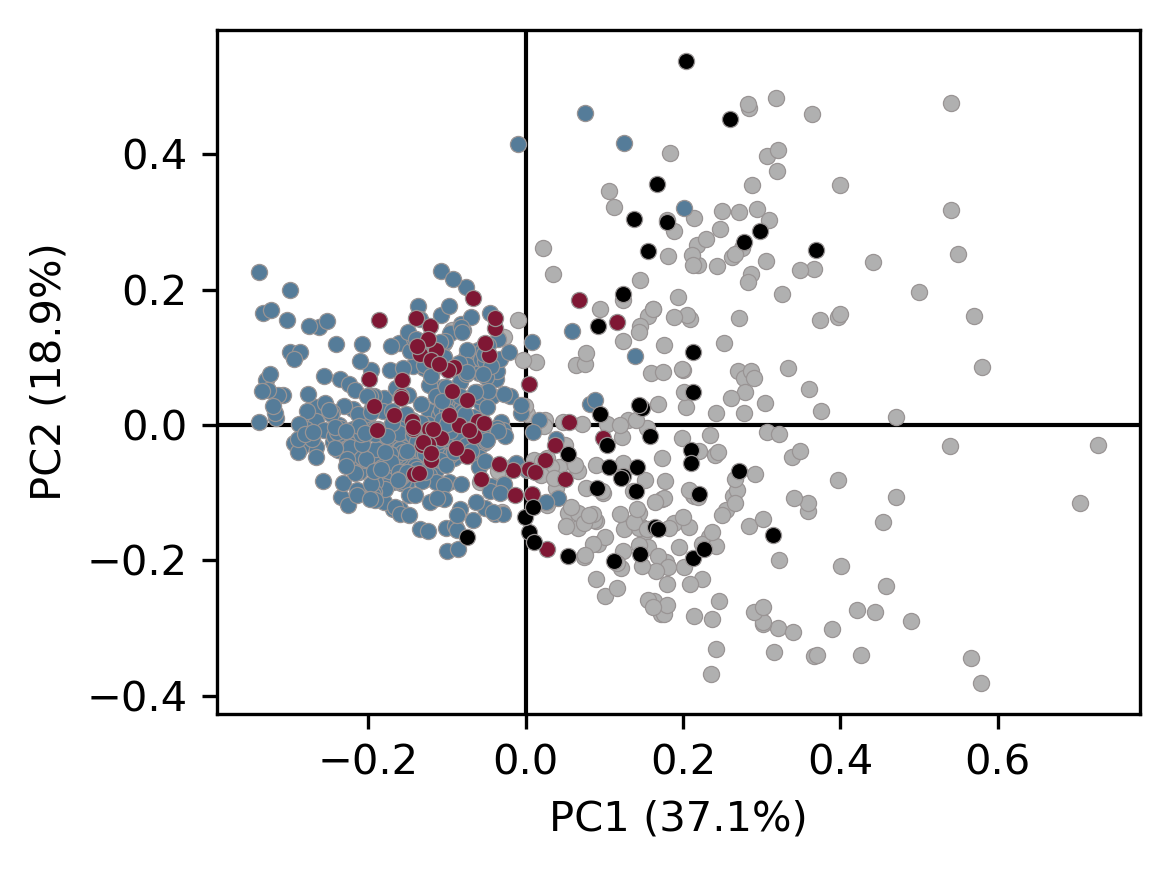

In [31]:
from sklearn.decomposition import PCA

PC1 = "PC1"
PC2 = "PC2"

pca = PCA(n_components=8, random_state=42)
P = pca.fit_transform(X)                      # (n, 2)
ev = pca.explained_variance_ratio_ * 100
plot_df[PC1], plot_df[PC2] = P[:, 0], P[:, 1]

plt.figure(figsize=(4, 3), dpi=300)
ax = plt.gca()

# highlighted zero-axes (drawn under the points)
ax.axhline(0, color="black", lw=1.0, zorder=0)
ax.axvline(0, color="black", lw=1.0, zorder=0)

for g in ["the rest", "class 2", "class 1", "neurotransmitter"]:
    sub = plot_df[plot_df["color_group"] == g]
    plt.scatter(sub[PC1], sub[PC2], s=15, alpha=1, edgecolors="#999494", linewidth=0.3,
                color=palette[g],
                label=f"{g} (n={len(sub)})", zorder=2)

plt.xlabel(f"{PC1} ({ev[0]:.1f}%)")
plt.ylabel(f"{PC2} ({ev[1]:.1f}%)")
#plt.legend(title="group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=6)

plt.tight_layout()
plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_pca_ORclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_pca_ORclass.png", bbox_inches="tight", dpi=300)
plt.show()

## UMAP parameter sweep (view only, not saved)

Every combination of:
- `min_dist` = 0.1, 0.2, … 0.9 (9)
- `n_neighbors` = 10, 20, … 100 (10)
- `metric` = cosine, euclidean, manhattan, correlation, hamming, hellinger (6)

= **540 plots**, each titled with `metric | n_neighbors | min_dist`. Nothing is saved.

Note: `hamming` and `hellinger` are defined for discrete / non-negative (probability) data,
so on continuous ESM embeddings they are largely uninformative — `hellinger` errors on
negative values and is skipped (caught and reported). `random_state=42` keeps each layout
reproducible but forces single-threaded UMAP, so the full sweep is slow.

In [ ]:
# import itertools
# import umap

# min_dists   = [round(0.1 * i, 1) for i in range(1, 10)]   # 0.1 .. 0.9
# n_neighbors = list(range(10, 101, 10))                     # 10 .. 100
# metrics     = ["cosine", "euclidean", "manhattan", "correlation", "hamming", "hellinger"]

# draw_order = ["the rest", "class 2", "class 1", "neurotransmitter"]
# combos = list(itertools.product(metrics, n_neighbors, min_dists))
# print(f"{len(combos)} combinations")

# for i, (metric, nn, md) in enumerate(combos, 1):
#     try:
#         reducer = umap.UMAP(n_neighbors=nn, min_dist=md, metric=metric, random_state=42)
#         Zi = reducer.fit_transform(X)
#     except Exception as e:
#         print(f"[{i}/{len(combos)}] skip  metric={metric} n_neighbors={nn} min_dist={md}: {e}")
#         continue

#     plt.figure(figsize=(3.6, 2.9), dpi=90)
#     for g in draw_order:
#         m = (df["color_group"] == g).to_numpy()
#         plt.scatter(Zi[m, 0], Zi[m, 1], s=7, alpha=0.85,
#                     color=palette[g], edgecolors="none")
#     plt.title(f"metric={metric} | n_neighbors={nn} | min_dist={md}", fontsize=8)
#     plt.xticks([]); plt.yticks([])
#     plt.tight_layout()
#     plt.show()
#     plt.close()

## 4. Embedding distance vs phylogenetic (patristic) distance

For every pair of proteins, compare:
- **phylogenetic distance** = patristic distance (sum of branch lengths between the two leaves)
  from `PF00001.9606.clustalo.gt01.lg.fasttree`, via `ete4`'s `cophenetic_matrix()`.
- **embedding distance** = cosine distance between the mean-pooled ESM vectors (matching the UMAP).

The two matrices are aligned by leaf id (`9606.<uniprot>`) on the intersection of tree leaves and
embeddings (warn + proceed if any id is missing). Pairs are coloured by OR-class membership (from
`color_group`): **class 1 × class 1** red, **class 2 × class 2** blue, **class 1 × class 2** the
50/50 blend; pairs touching a neurotransmitter or "the rest" receptor are grey. Pairs are not
independent, so treat the correlation as descriptive.

pairs: 260,281   Pearson r = 0.677   Spearman rho = 0.656
mix colour: #6a4a66   |   class1-class1=1,891  class2-class2=69,006  class1-class2=23,064  nt-nt=861  other=165,459


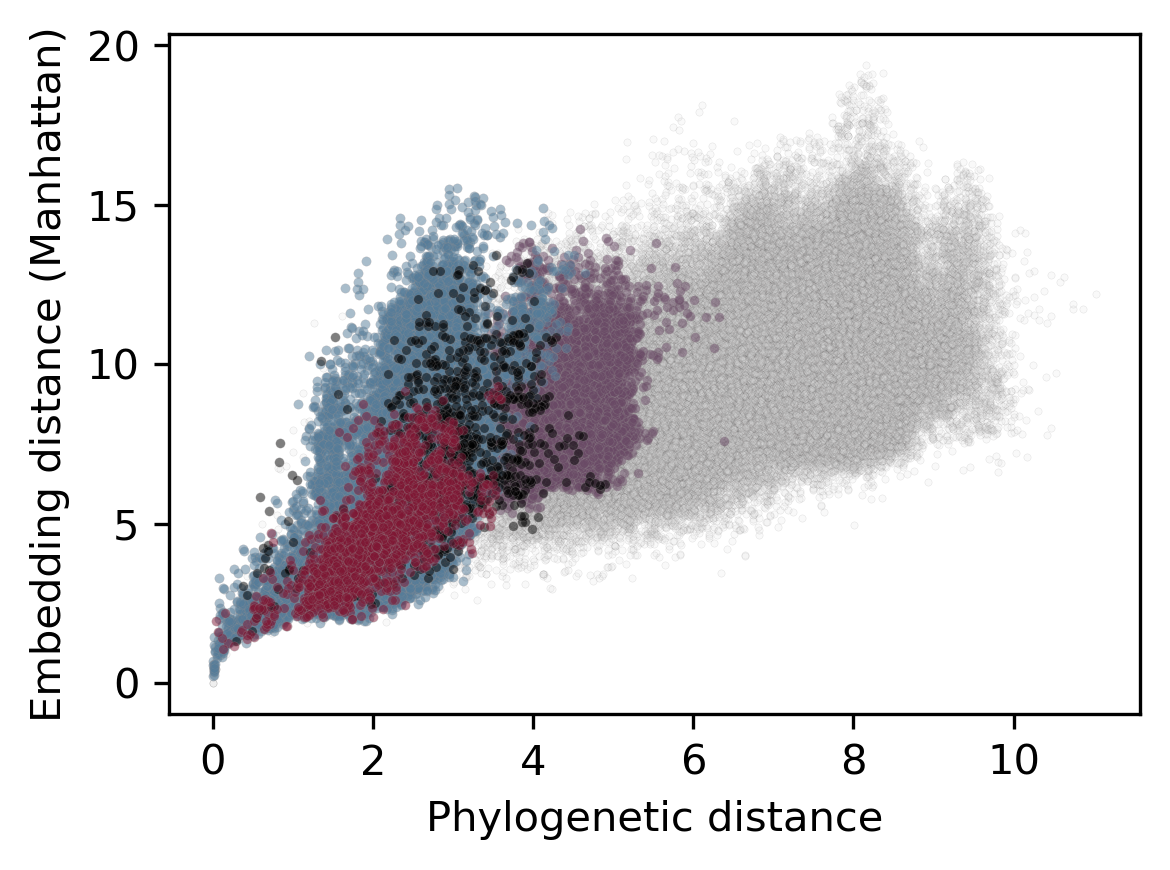

In [27]:
# ---- Embedding distance vs phylogenetic (patristic) distance, coloured by OR-class pair ----
from ete4 import PhyloTree
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

TREE_PATH = AP / "PF00001.9606.clustalo.gt01.lg.fasttree"

# patristic distances (branch-length distances between leaves); fasttree newick -> parser=0
phy = PhyloTree(open(TREE_PATH).read(), parser=0)
cophen, leaf_names = phy.cophenetic_matrix()
D_phylo_full = np.asarray(cophen, dtype=float)
name_idx = {n: i for i, n in enumerate(leaf_names)}

# align tree to embeddings on the intersection (warn + proceed if any id is missing)
meta_ids = (df["tax_id"].astype(str) + "." + df["uniprot"].astype(str)).values
in_tree = np.array([m in name_idx for m in meta_ids])
if (~in_tree).any():
    print(f"WARN: {int((~in_tree).sum())} embedding(s) absent from tree, dropped: "
          f"{sorted(meta_ids[~in_tree])[:5]}")
keep    = np.where(in_tree)[0]
Xk      = X[keep]
cg      = df["color_group"].to_numpy()[keep]
order   = [name_idx[meta_ids[i]] for i in keep]
D_phylo = D_phylo_full[np.ix_(order, order)]          # row i == Xk[i]

# embedding distances (Manhattan / cityblock; use "cosine" for cosine distance)
D_emb = squareform(pdist(Xk, metric="cityblock"))

# upper triangle = unique pairs
iu = np.triu_indices(len(Xk), k=1)
phylo_d, emb_d = D_phylo[iu], D_emb[iu]

r, _   = pearsonr(phylo_d, emb_d)
rho, _ = spearmanr(phylo_d, emb_d)
print(f"pairs: {len(phylo_d):,}   Pearson r = {r:.3f}   Spearman rho = {rho:.3f}")

# ---- classify each pair (class 1 / class 2 / neurotransmitter; 'the rest' -> None) ----
cls = np.array([c if c in ("class 1", "class 2", "neurotransmitter") else None for c in cg], dtype=object)
ci, cj = cls[iu[0]], cls[iu[1]]
both1   = (ci == "class 1") & (cj == "class 1")
both2   = (ci == "class 2") & (cj == "class 2")
both_nt = (ci == "neurotransmitter") & (cj == "neurotransmitter")
cross   = ((ci == "class 1") & (cj == "class 2")) | ((ci == "class 2") & (cj == "class 1"))
other   = ~(both1 | both2 | both_nt | cross)           # any pair touching "the rest" / mixed groups

RED, BLUE, BLACK = palette["class 1"], palette["class 2"], "#000000"
def hex_blend(h1, h2, t=0.5):
    a = np.array([int(h1[k:k+2], 16) for k in (1, 3, 5)])
    b = np.array([int(h2[k:k+2], 16) for k in (1, 3, 5)])
    return "#%02x%02x%02x" % tuple(np.round((1 - t) * a + t * b).astype(int))
MIX = hex_blend(RED, BLUE, 0.5)   # mix of class-1 red and class-2 blue
print(f"mix colour: {MIX}   |   class1-class1={both1.sum():,}  class2-class2={both2.sum():,}  "
      f"class1-class2={cross.sum():,}  nt-nt={both_nt.sum():,}  other={other.sum():,}")

EDGE_HL, EDGE_REST, LW = "#999494", "#312D2D", 0.1   # highlighted vs 'the rest' edge colours

plt.figure(figsize=(4, 3), dpi=300)
# background: pairs touching a non-class / mixed-group receptor -> darker edge
plt.scatter(phylo_d[other], emb_d[other], s=3, alpha=0.15, c="#D9D9D9",
            edgecolors=EDGE_REST, linewidth=LW, label=f"other (n={other.sum():,})", rasterized=True)
# highlighted pair classes on top -> lighter edge
for mask, color, lab in [(cross,   MIX,   f"class 1 × class 2 (n={cross.sum():,})"),
                         (both2,   BLUE,  f"class 2 × class 2 (n={both2.sum():,})"),
                         (both_nt, BLACK, f"neurotransmitter (n={both_nt.sum():,})"),
                         (both1,   RED,   f"class 1 × class 1 (n={both1.sum():,})")]:
    plt.scatter(phylo_d[mask], emb_d[mask], s=5, alpha=0.5, c=color,
                edgecolors=EDGE_HL, linewidth=LW, label=lab, rasterized=True)

plt.xlabel("Phylogenetic distance")
plt.ylabel("Embedding distance (Manhattan)")
#plt.title(f"Embedding vs phylogenetic distance\n"
#          f"Pearson r={r:.3f}, Spearman ρ={rho:.3f}  (n={len(phylo_d):,} pairs)")
#plt.legend(fontsize=6, frameon=False, markerscale=1.5, loc="lower right")
plt.tight_layout()
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_embedding_vs_phylo_distance_byclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_embedding_vs_phylo_distance_byclass.png", bbox_inches="tight", dpi=300)
plt.show()

## 5. Per-class slopes (Mantel, bootstrap bands, partial correlation)

Three statistics on the same `phylo_d` / `emb_d` and pair-class masks from the cell above:
1. **Mantel test** (permuting taxa, not pairs) — a permutation p-value for the matrix
   correlation, which the raw Pearson/Spearman cannot give (the pairs are not independent).
2. **Per-class slopes with 95% bootstrap bands** — OLS slope of embedding vs phylogenetic
   distance within each pair category (class 1 / class 2 / class 1×2 / neurotransmitter / other),
   bands from a **receptor-level bootstrap**. The class 1 vs class 2 slope *difference* is tested.
3. **Partial correlation conditioning on pair-category** — how much association survives once the
   between-group structure is removed.

> `PERMS` controls Mantel cost (each perm correlates all 260k pairs); raise for a finer p-value.

[1] Mantel (999 perms):  Spearman r=0.656 (p=0.0010)   Pearson r=0.677 (p=0.0010)
[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B=500):
      class 1 × class 1   slope=1.867  CI[1.583, 2.167]
      class 2 × class 2   slope=2.747  CI[2.539, 2.952]
      class 1 × class 2   slope=0.479  CI[0.115, 0.874]
      neurotransmitter    slope=1.277  CI[0.778, 1.749]
      other               slope=0.629  CI[0.547, 0.706]
      class1 - class2 slope = -0.880  CI[-1.234, -0.519]  bootstrap p=0.000
[3] partial corr | pair-category:  Spearman 0.656 -> 0.335   Pearson 0.677 -> 0.388


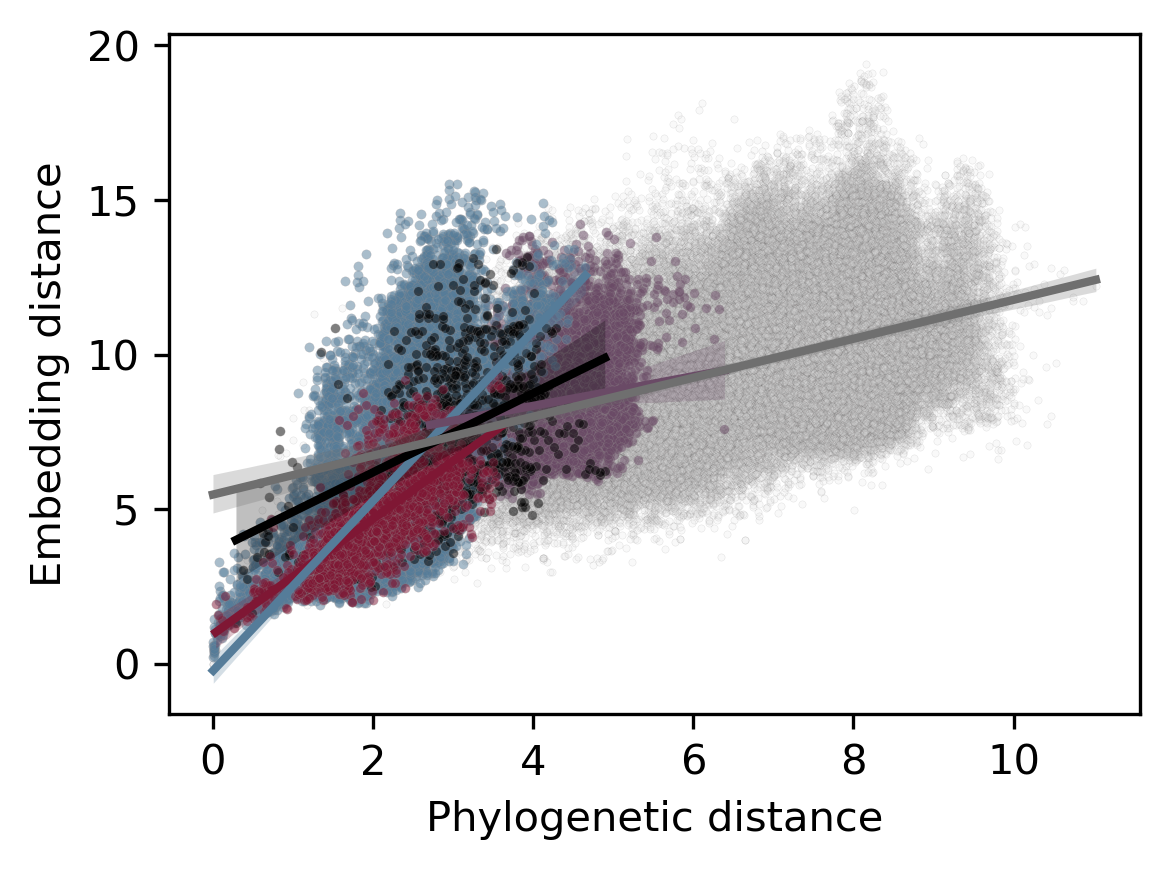

In [30]:
# ---- Per-class slopes: Mantel, receptor-level bootstrap bands, partial correlation ----
from scipy.stats import rankdata

n = len(Xk)
GREY = "#B0B0B0"
cat_defs = [("class 1 × class 1", both1,   RED),
            ("class 2 × class 2", both2,   BLUE),
            ("class 1 × class 2", cross,   MIX),
            ("neurotransmitter",  both_nt, BLACK),
            ("other",             other,   GREY)]

# ---------- 1. Mantel test (permute taxa) ----------
def _rank_mat(Dm):
    R = np.zeros_like(Dm); R[iu] = rankdata(Dm[iu]); return R + R.T

def mantel(Dx, Dy, perms=999, method="spearman", seed=0):
    if method == "spearman":
        Dx, Dy = _rank_mat(Dx), _rank_mat(Dy)
    x = Dx[iu]; obs = np.corrcoef(x, Dy[iu])[0, 1]
    rng = np.random.default_rng(seed); ge = 0
    for _ in range(perms):
        p = rng.permutation(n)
        ge += np.corrcoef(x, Dy[np.ix_(p, p)][iu])[0, 1] >= obs
    return obs, (ge + 1) / (perms + 1)

PERMS = 999   # raise for a finer p-value (slower: each perm correlates all pairs)
m_rho, p_rho = mantel(D_phylo, D_emb, PERMS, "spearman")
m_r,   p_r   = mantel(D_phylo, D_emb, PERMS, "pearson")

# ---------- 2. per-class slopes + receptor-level bootstrap bands ----------
def slope_int(x, y):
    m, b = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
    return m, b

point = {lab: slope_int(phylo_d[mk], emb_d[mk]) for lab, mk, _ in cat_defs}

B = 500
rng = np.random.default_rng(1)
boot = {lab: {"m": [], "b": []} for lab, _, _ in cat_defs}
diff_c1_c2 = []
for _ in range(B):
    bs = rng.integers(0, n, n)                         # resample receptors (taxa)
    Dp = D_phylo[np.ix_(bs, bs)][iu]; De = D_emb[np.ix_(bs, bs)][iu]
    cb = cls[bs]; cbi, cbj = cb[iu[0]], cb[iu[1]]
    b1  = (cbi == "class 1") & (cbj == "class 1")
    b2  = (cbi == "class 2") & (cbj == "class 2")
    bnt = (cbi == "neurotransmitter") & (cbj == "neurotransmitter")
    cx  = ((cbi == "class 1") & (cbj == "class 2")) | ((cbi == "class 2") & (cbj == "class 1"))
    ot  = ~(b1 | b2 | bnt | cx)
    nz  = Dp > 0                                       # drop duplicate-origin zero-distance pairs
    s = {}
    for lab, mk in [("class 1 × class 1", b1), ("class 2 × class 2", b2),
                    ("class 1 × class 2", cx), ("neurotransmitter", bnt), ("other", ot)]:
        mm = mk & nz
        if mm.sum() > 2:
            m, b = slope_int(Dp[mm], De[mm]); boot[lab]["m"].append(m); boot[lab]["b"].append(b); s[lab] = m
    if "class 1 × class 1" in s and "class 2 × class 2" in s:
        diff_c1_c2.append(s["class 1 × class 1"] - s["class 2 × class 2"])

diff_c1_c2 = np.array(diff_c1_c2)
d_lo, d_hi = np.percentile(diff_c1_c2, [2.5, 97.5])
p_diff = 2 * min((diff_c1_c2 > 0).mean(), (diff_c1_c2 < 0).mean())

# ---------- 3. partial correlation conditioning on pair-category ----------
pairtype = np.select([both1, both2, cross, both_nt], ["c1", "c2", "cx", "nt"], default="ot")
Z = np.hstack([np.ones((len(pairtype), 1)),
               pd.get_dummies(pairtype, drop_first=True).values.astype(float)])
def _resid(y):  return y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
def partial(x, y): return np.corrcoef(_resid(x), _resid(y))[0, 1]
raw_r   = np.corrcoef(phylo_d, emb_d)[0, 1]
raw_rho = np.corrcoef(rankdata(phylo_d), rankdata(emb_d))[0, 1]
par_r   = partial(phylo_d.astype(float), emb_d.astype(float))
par_rho = partial(rankdata(phylo_d).astype(float), rankdata(emb_d).astype(float))

# ---------- report ----------
print(f"[1] Mantel ({PERMS} perms):  Spearman r={m_rho:.3f} (p={p_rho:.4f})   "
      f"Pearson r={m_r:.3f} (p={p_r:.4f})")
print(f"[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B={B}):")
for lab, _, _ in cat_defs:
    arr = np.array(boot[lab]["m"]); lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"      {lab:18}  slope={point[lab][0]:.3f}  CI[{lo:.3f}, {hi:.3f}]")
print(f"      class1 - class2 slope = {point['class 1 × class 1'][0]-point['class 2 × class 2'][0]:.3f}  "
      f"CI[{d_lo:.3f}, {d_hi:.3f}]  bootstrap p={p_diff:.3f}")
print(f"[3] partial corr | pair-category:  Spearman {raw_rho:.3f} -> {par_rho:.3f}   "
      f"Pearson {raw_r:.3f} -> {par_r:.3f}")

# ---------- plot: per-class regression lines + bootstrap confidence bands ----------
EDGE_HL, EDGE_REST, LW = "#999494", "#312D2D", 0.1   # highlighted vs 'the rest' edge colours

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
# dots styled like the distance cell: 'other' faint with dark edge; highlighted on top with light edge
ax.scatter(phylo_d[other], emb_d[other], s=3, alpha=0.15, c="#D9D9D9",
           edgecolors=EDGE_REST, linewidth=LW, rasterized=True)
for lab, mk, col in [("class 1 × class 2", cross,   MIX),
                     ("class 2 × class 2", both2,   BLUE),
                     ("neurotransmitter",  both_nt, BLACK),
                     ("class 1 × class 1", both1,   RED)]:
    ax.scatter(phylo_d[mk], emb_d[mk], s=5, alpha=0.5, c=col,
               edgecolors=EDGE_HL, linewidth=LW, rasterized=True)

for lab, mk, col in cat_defs:
    xg = np.linspace(phylo_d[mk].min(), phylo_d[mk].max(), 100)
    ms = np.array(boot[lab]["m"]); bs_ = np.array(boot[lab]["b"])
    preds = ms[:, None] * xg[None, :] + bs_[:, None]
    lo, hi = np.percentile(preds, [2.5, 97.5], axis=0)
    line_c = "#6f6f6f" if lab == "other" else col
    ax.fill_between(xg, lo, hi, color=line_c, alpha=0.25, lw=0)
    ax.plot(xg, point[lab][0] * xg + point[lab][1], color=line_c, lw=2,
            label=f"{lab} (slope {point[lab][0]:.2f})")
ax.set_xlabel("Phylogenetic distance")
ax.set_ylabel("Embedding distance")
#ax.set_title(f"Per-class slopes ±95% bootstrap band\n"
#             f"Mantel ρ={m_rho:.3f} (p={p_rho:.4f}); partial ρ|class={par_rho:.3f}")
#ax.legend(fontsize=6, frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_distances_slopes.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "gpcr_pf00001_esmc300m_distances_slopes.png", bbox_inches="tight", dpi=300)
plt.show()